In [1]:
# import os
# os.chdir("../..")

from occultence import *
import occultence
occultence.version()

'0.5.5'

(0.99, 1.015)

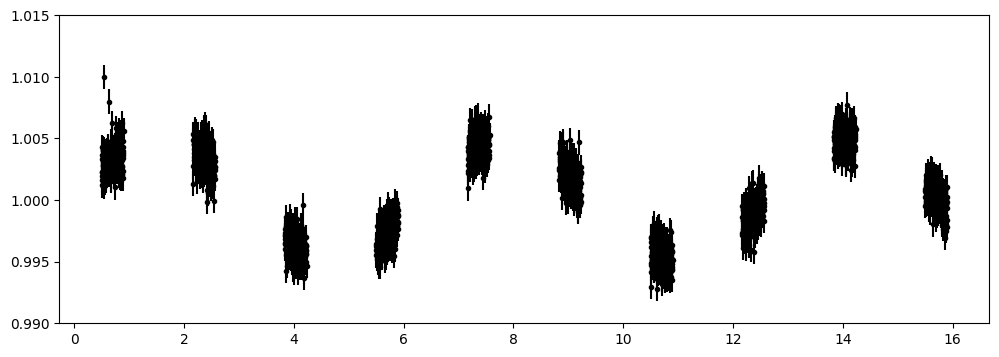

In [2]:
t = list(np.linspace(0.5,0.9,200))
daylength = len(t)
ndays = 10
gap = 16/24.
A = 0.005

for d in range(1,ndays):
    t.extend(np.array(t[:daylength]) + d * (1 + gap))

t = np.array(t)
ferr = 1e-3 * np.ones(len(t))
sinusoid_trend = A * np.sin(t)
f = 1 + sinusoid_trend + (ferr * (np.random.randn(len(t))))
f[22] = 1.01 # add a cosmic
f[63] = 1.008 # add a cosmic
f[50] = 0.0 # add a zero flux point

# f *= np.linspace(1,1.01, len(t)) # add a linear trend for the GP to remove
plt.figure(figsize=(12,4))
plt.errorbar(t,f,ferr,fmt='k.')
plt.ylim(0.99,1.015)

In [3]:
targ = LightCurve(name = "test",
                  time = t,
                  flux = f,
                  uncertainty = np.abs(ferr),
                  telescope = "None",
                  filter="None",
                  metadata={'R_star':0.1*u.R_sun, 'M_star':0.1*u.M_sun})

🤖⚠ Warning! The time array is not an astropy.Time object, therefore there is no info about the 
format or scale.
We will assume that it is JD and TDB from here on! ⚠🤖



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Time [d]'>],
      dtype=object)

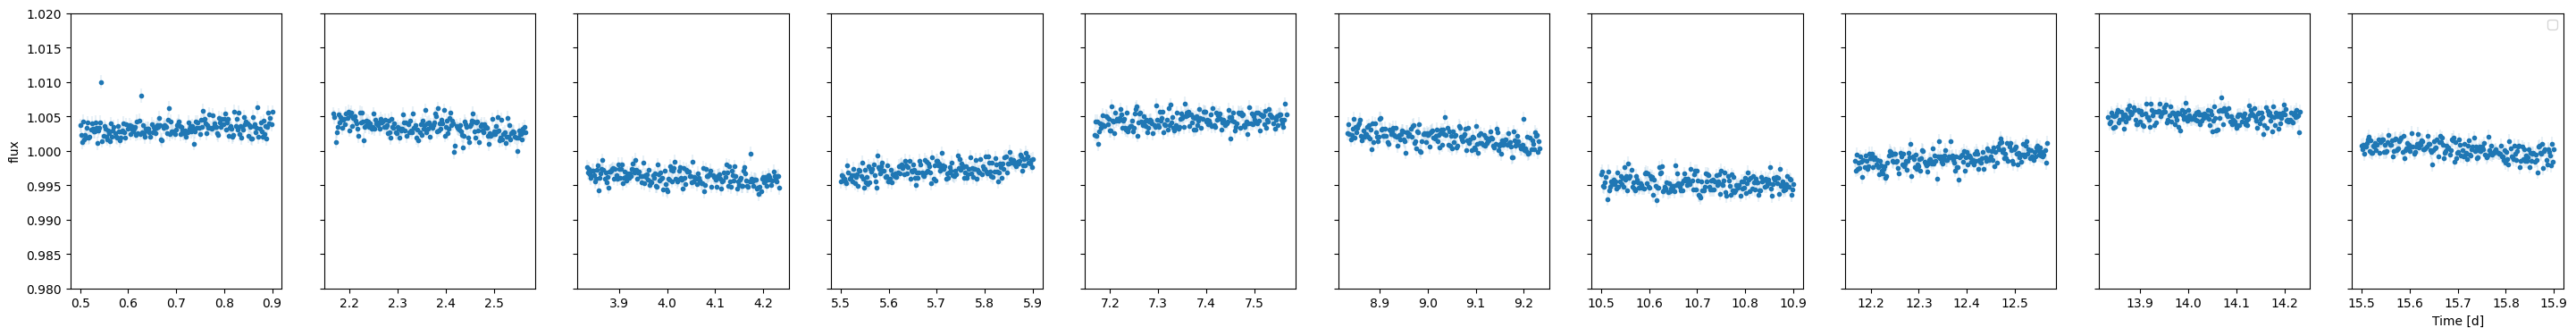

In [4]:
targ.plot()

In [10]:
targ.split_day(0).normalize().metadata

{'name': 'test_normalized',
 'target': 'test',
 'R_star': <Quantity 0.1 solRad>,
 'M_star': <Quantity 0.1 solMass>,
 'norm_og_median': 1.0032844914648895}

In [17]:
def normalize_each_night(self, **kw):
    """
    Perform normalization for each night in the light curve timeseries.
    :param self: LightCurve object
    :param kw: keywords to pass to self.gp_detrend
    :return: normalized LightCurve object
    """
    norm_days = []
    for i in range(self.ndays):
        norm_days.append(normalize(self.split_day(i), **kw))

    reconst = norm_days[0]
    for md in norm_days[1:]:
        reconst = reconst.concatenate(md)

    return reconst

def normalize(self, **kw):
    new_lc = self._create_copy()
    new_lc.timelike['flux'] = self.timelike['flux'] / np.nanmedian(self.timelike['flux'])

    new_lc.metadata['normalization'] = {'norm_og_median': np.nanmedian(self.timelike['flux'])}
    new_lc._set_name(new_lc.name + "_normalized")

    return new_lc

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Time [d]'>],
      dtype=object)

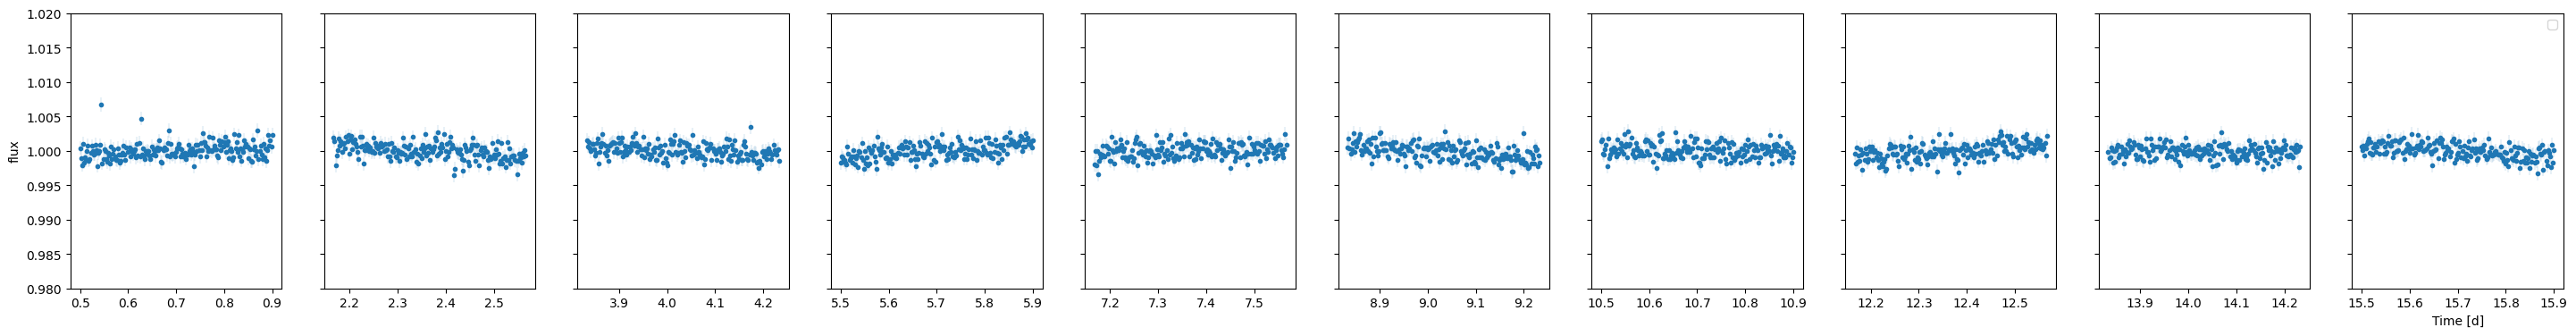

In [18]:
normalize_each_night(targ).plot()

In [19]:
normalize_each_night(targ).metadata

{'name': 'test_normalized',
 'target': 'test',
 'R_star': <Quantity 0.1 solRad>,
 'M_star': <Quantity 0.1 solMass>,
 'normalization': [{'norm_og_median': 1.0032844914648895},
  {'norm_og_median': 1.0034508503941273},
  {'norm_og_median': 0.996160535451406},
  {'norm_og_median': 0.9972432150578059},
  {'norm_og_median': 1.004352429104613},
  {'norm_og_median': 1.0020759757951434},
  {'norm_og_median': 0.9952645356632047},
  {'norm_og_median': 0.9989572805049076},
  {'norm_og_median': 1.0050886325639912},
  {'norm_og_median': 1.0001871541471001}]}

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/occultence/flare_finding/flare_model.py:207: RuntimeWarning: overflow encountered in exp
  * np.exp(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Time [d]'>],
      dtype=object)

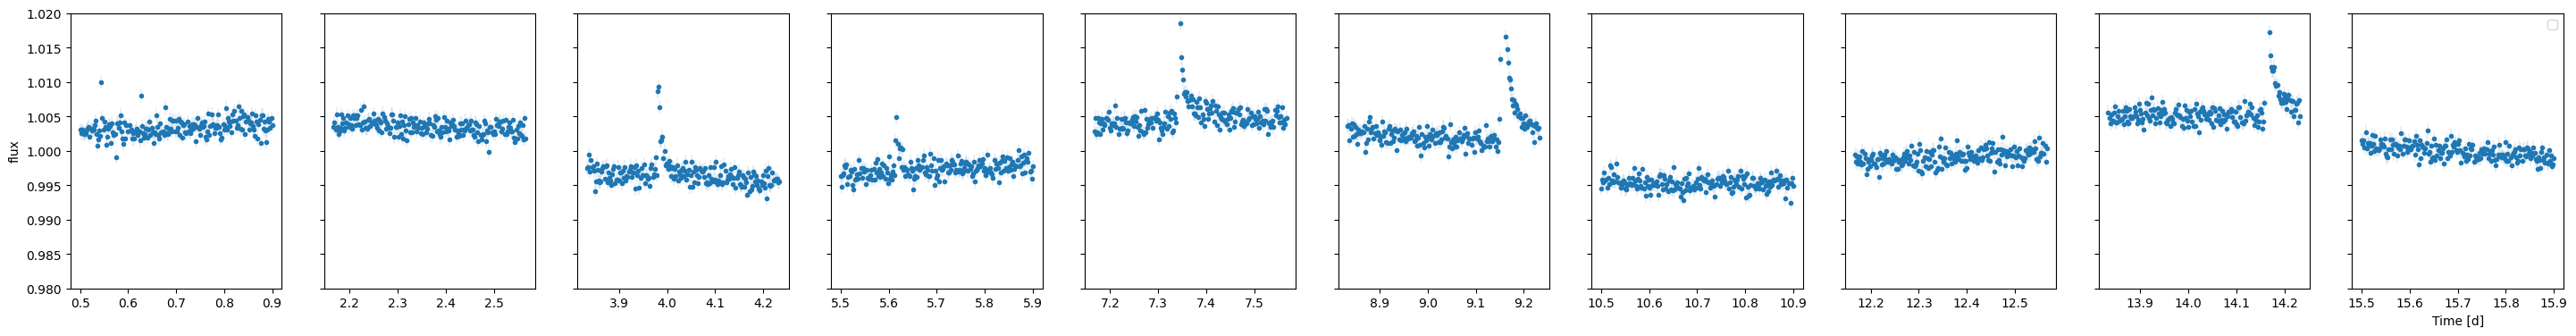

In [45]:
flare_lc = targ.inject_flares(nfake=5, amp_range=[1e-3, 0.05], model="mendoza2022")
flare_lc.plot()

In [5]:
flare_lc.metadata

{'name': 'test_injectedflares',
 'target': 'test',
 'R_star': <Quantity 0.1 solRad>,
 'M_star': <Quantity 0.1 solMass>,
 'flares_injected': {'nflares_injected': 5,
  'flare_params': {'t0': [12.418000824435966,
    9.030430889103524,
    2.4156294682161157,
    2.218422221851363,
    2.3499802971934676],
   'fwhm': [0.007691364453566664,
    0.007900927800909084,
    0.0057513972911019265,
    0.007592667387506537,
    0.007373460551913284],
   'amp': [0.011298058398368348,
    0.020712921467307594,
    0.043971963690704954,
    0.02265759046810687,
    0.01740881118894179]}}}

In [6]:
flare_lc.split_by

<Quantity 0.5 d>

In [7]:
i_split, _ = flare_lc.split_time(split=flare_lc.split_by)
i_split

[0, 200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]

In [8]:
clip_lc = flare_lc.global_and_local_sigma_clip(global_sc_kw={'nsigma_upper':5, 
                                                             'nsigma_lower':5},
                                               local_sc_kw={'nsigma_upper':3, 
                                                            'nsigma_lower':np.inf, 
                                                            'running_mean_boxsize':0.4}
                                              )

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Time [d]'>],
      dtype=object)

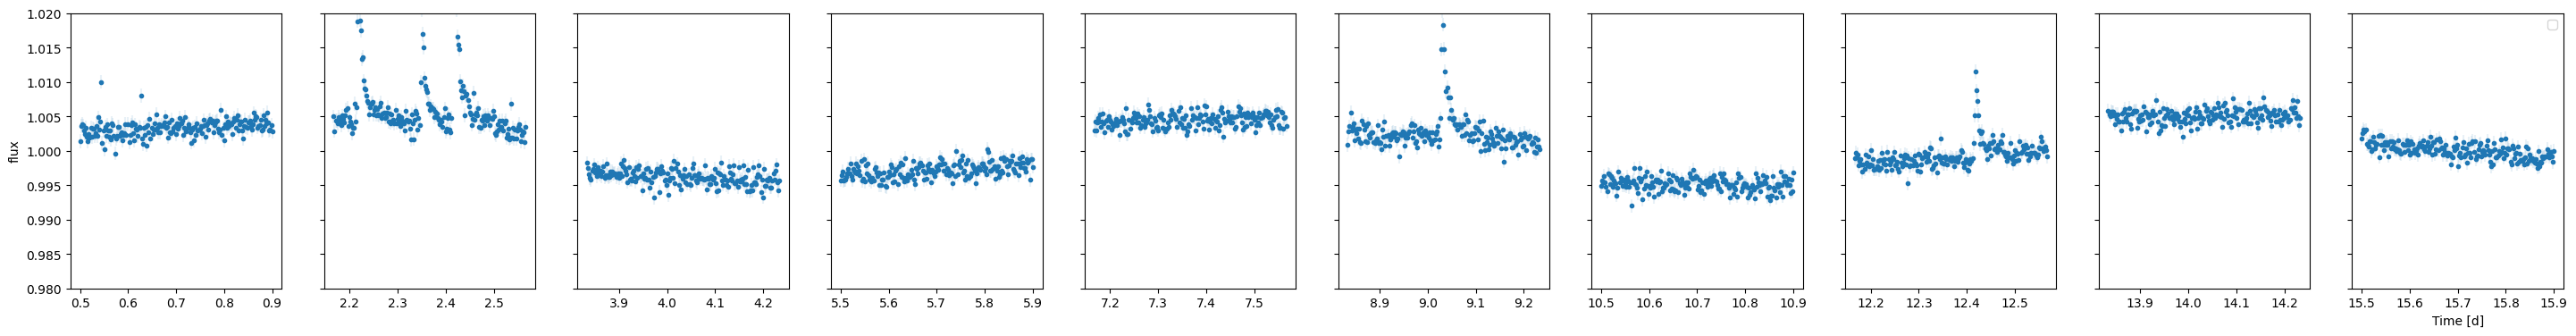

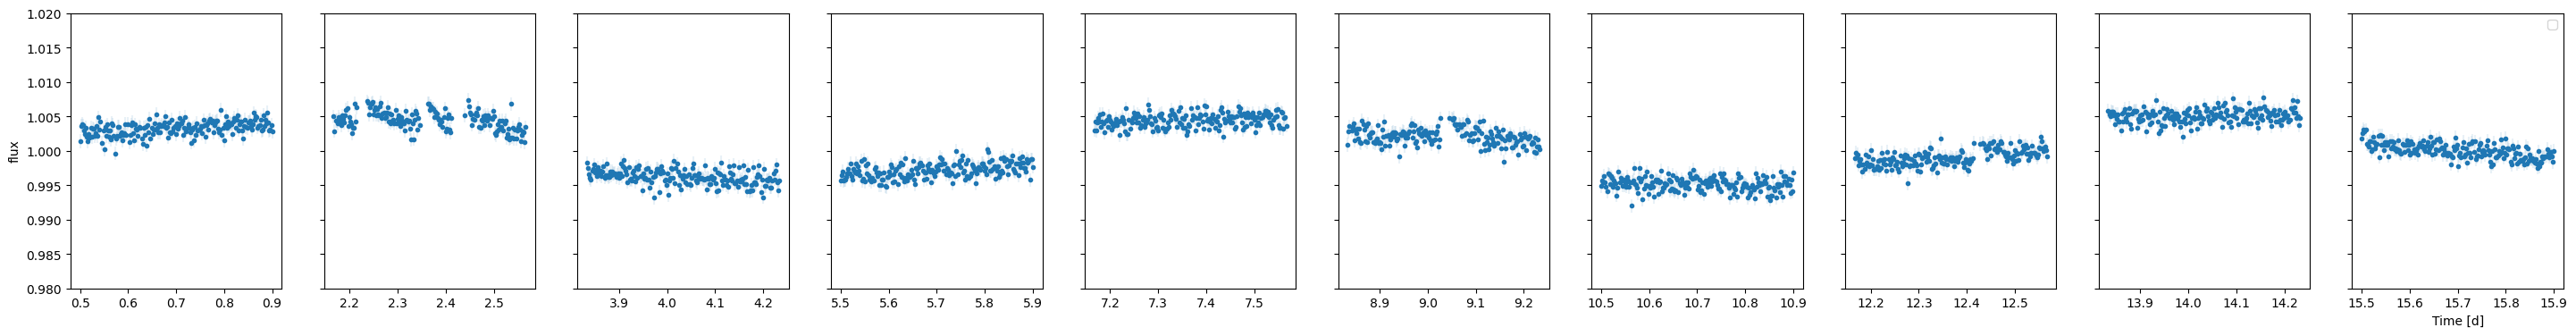

In [9]:
flare_lc.plot()
clip_lc.plot()

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


The best recovered period=6.126001657916551 d


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


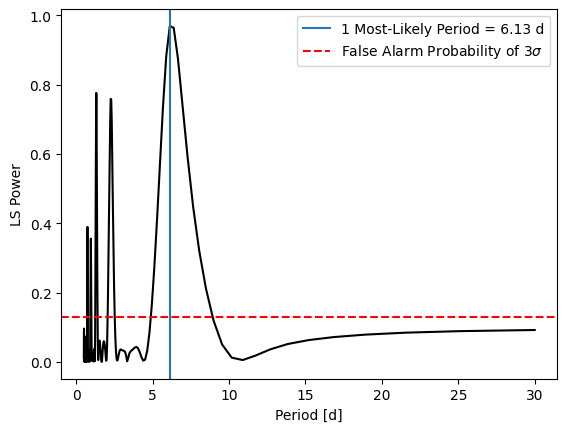

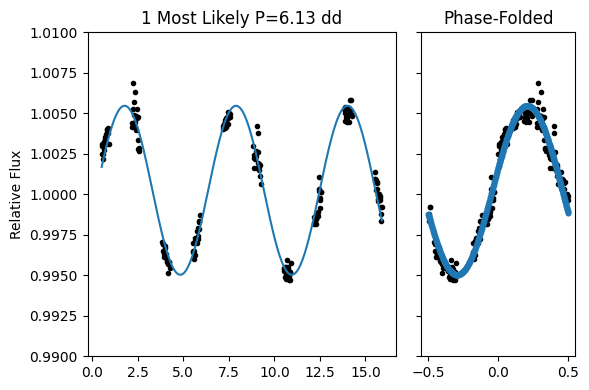

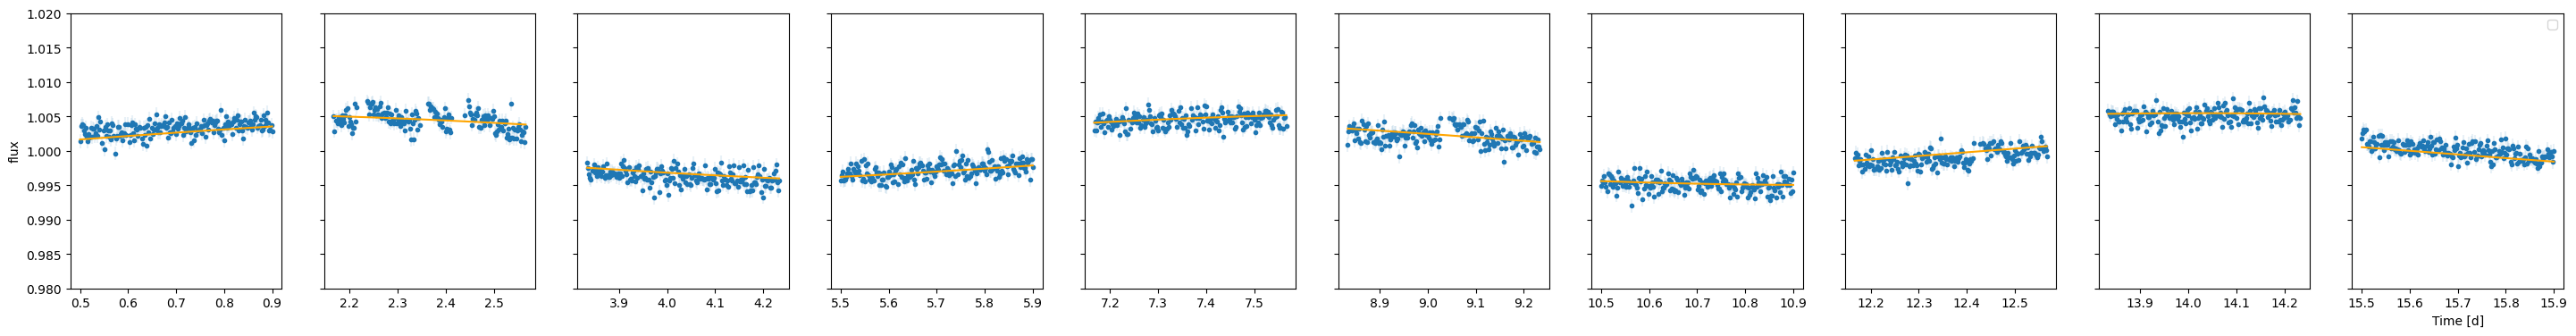

In [10]:
detrended_targ = clip_lc.lombscargle_detrend(plot=True, ls_binning=30*u.minute,
                                  minimum_frequency=1/(30*u.d),
                                  maximum_frequency=1/(0.5*u.d),
                                  samples_per_peak=10,
                                  npeaks=1,
                                  nsigma=3)

In [11]:
flare_lc_detrended = flare_lc._create_copy()
flare_lc_detrended.timelike['flux'] = flare_lc_detrended.timelike['flux']/detrended_targ.timelike['ls_model']

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



            There are 5 flare candidates with >5.0 min over 3$\sigma$
            


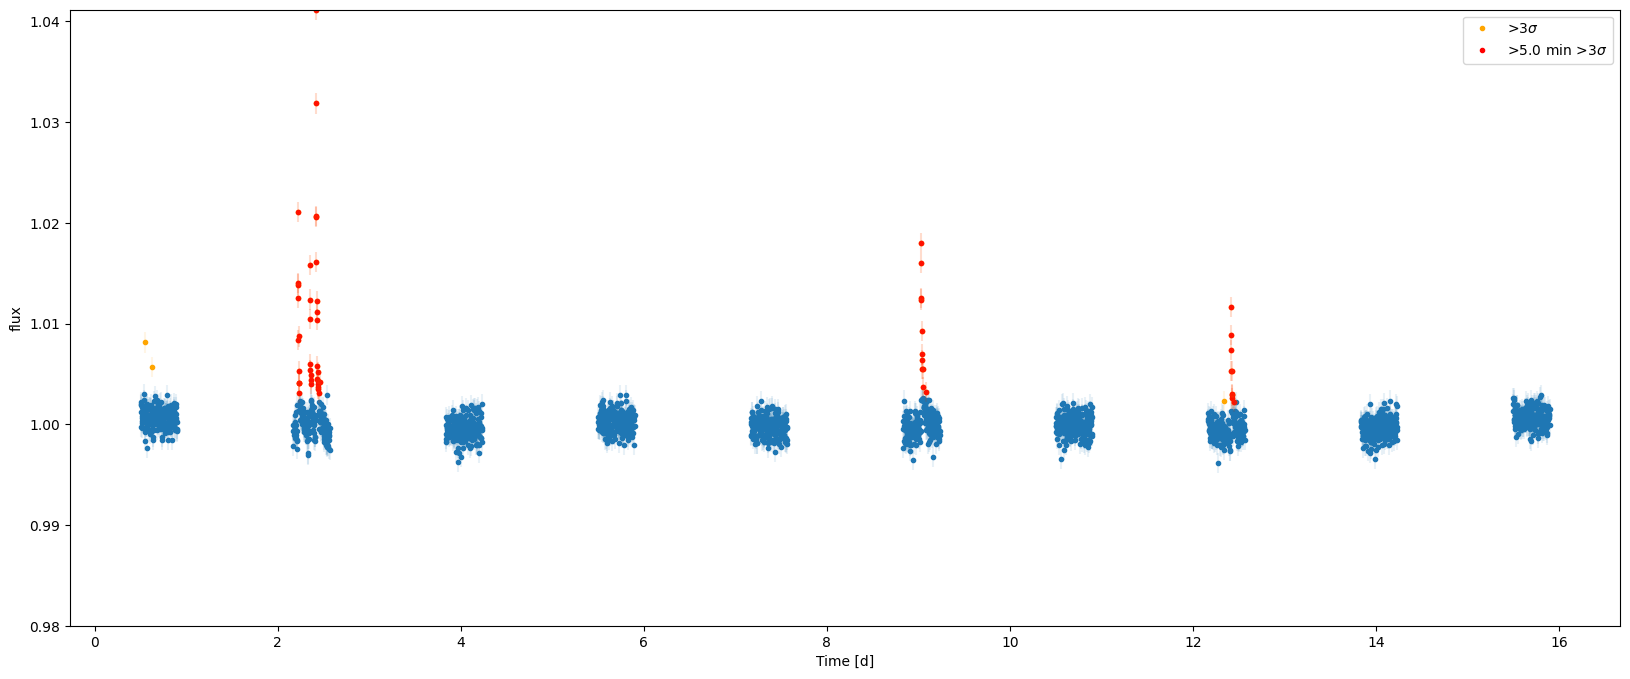

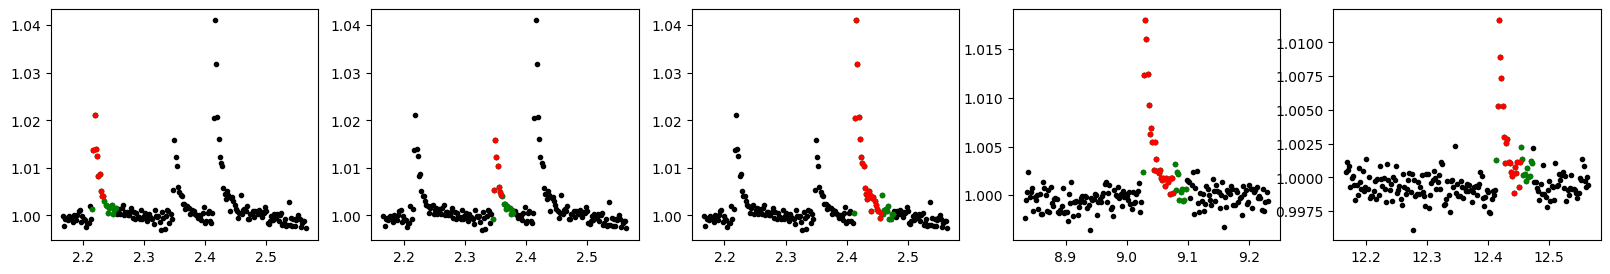

In [15]:
flares_masked = flare_lc_detrended.detect_flares_sclip(plot=True, 
                                                       min_flare_separation=60*u.minute,
                                                      tbuffer_after=30*u.min)

In [16]:
flares_masked.metadata

{'name': 'test_injectedflares_sigmaclipped_flaresremoved',
 'target': 'test',
 'R_star': <Quantity 0.1 solRad>,
 'M_star': <Quantity 0.1 solMass>,
 'flares_injected': {'nflares_injected': 5,
  'flare_params': {'t0': [12.418000824435966,
    9.030430889103524,
    2.4156294682161157,
    2.218422221851363,
    2.3499802971934676],
   'fwhm': [0.007691364453566664,
    0.007900927800909084,
    0.0057513972911019265,
    0.007592667387506537,
    0.007373460551913284],
   'amp': [0.011298058398368348,
    0.020712921467307594,
    0.043971963690704954,
    0.02265759046810687,
    0.01740881118894179]}},
 'flares_detected': {'nflares': 5,
  'thresholds': {'duration': <Quantity 5. min>,
   'sigma': 3,
   'separation': <Quantity 60. min>},
  'flare_regions': [[224, 244],
   [289, 307],
   [322, 355],
   [1096, 1132],
   [1523, 1553]],
  'flare_frequency': <Quantity 1.38888889 1 / d>,
  'global_sc_kw': {'nsigma_upper': 5, 'nsigma_lower': 5},
  'local_sc_kw': {'nsigma_upper': 3,
   'nsigma_l

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Time [d]'>],
      dtype=object)

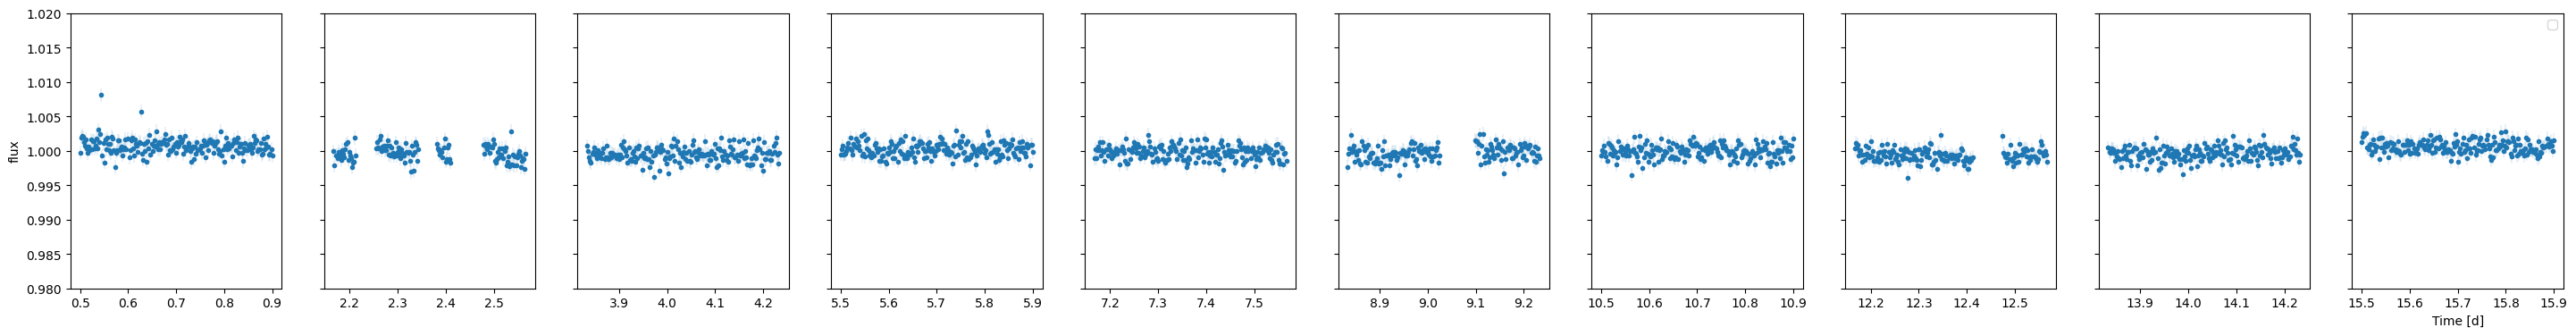

In [17]:
flares_masked.plot()

In [42]:
# flares_to_model = flares_masked.metadata['flares_detected']['flare_regions']
# flares_modeled = flares_masked.model_each_flare([1,1,1,1,1], 
#                                flare_lc_detrended.time.value, 
#                                flare_lc_detrended.flux, 
#                                flare_lc_detrended.uncertainty, 
#                                n_before=3, 
#                                n_after=5, 
#                                method="mendoza2022",
#                                tgap=(1 * u.hour).to_value('d'), 
#                                plot=True)

# flares_modeled.metadata

In [56]:
flares_masked

<🌟 Lightcurve test_injectedflares_sigmaclipped_flaresremoved (2000t) 🌟>

In [59]:
flares_masked.split_day(6)

<🌟 Lightcurve test_injectedflares_sigmaclipped_flaresremoved (200t) 🌟>

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.